## **<span style="color:red">- EDA - Univariate Analysis</span>**

<br>

#### **<span style="color:black">- Dataset</span>**

In [ ]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv')
df.shape

(3803, 21)

In [4]:
df.head()

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,7585.0,1081.0,3,2,2,NaN,New Property,...,NaN,650.0,0,0,0,0,0,semifurnished,Low Floor,Low
1,flat,sector 89,0.95,8600.0,1105.0,2,2,2,NaN,New Property,...,NaN,1103.0,1,1,0,0,0,semifurnished,Mid Floor,Low
2,flat,sector 86,0.46,79.0,58228.0,2,2,1,NaN,Under Construction,...,NaN,58141.0,0,0,0,0,0,semifurnished,Low Floor,Low
3,flat,sohna road,0.32,5470.0,585.0,2,2,1,NaN,New Property,...,1000.0,585.0,0,0,0,0,0,semifurnished,High Floor,Low
4,flat,sector 92,1.60,8020.0,1995.0,3,4,3+,North-West,Relatively New,...,1615.0,1476.0,0,1,0,0,1,furnished,Mid Floor,High


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3803 non-null   object 
 1   sector               3803 non-null   object 
 2   price                3785 non-null   float64
 3   price_per_sqft       3785 non-null   float64
 4   area                 3785 non-null   float64
 5   bedRoom              3803 non-null   int64  
 6   bathroom             3803 non-null   int64  
 7   balcony              3803 non-null   object 
 8   facing               2698 non-null   object 
 9   agePossession        3803 non-null   object 
 10  super_built_up_area  1915 non-null   float64
 11  built_up_area        1733 non-null   float64
 12  carpet_area          1944 non-null   float64
 13  study room           3803 non-null   int64  
 14  servant room         3803 non-null   int64  
 15  store room           3803 non-null   i

In [8]:
print("Duplicates: ",df.duplicated().sum())

Duplicates:  128


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.head()

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,7585.0,1081.0,3,2,2,NaN,New Property,...,NaN,650.0,0,0,0,0,0,semifurnished,Low Floor,Low
1,flat,sector 89,0.95,8600.0,1105.0,2,2,2,NaN,New Property,...,NaN,1103.0,1,1,0,0,0,semifurnished,Mid Floor,Low
2,flat,sector 86,0.46,79.0,58228.0,2,2,1,NaN,Under Construction,...,NaN,58141.0,0,0,0,0,0,semifurnished,Low Floor,Low
3,flat,sohna road,0.32,5470.0,585.0,2,2,1,NaN,New Property,...,1000.0,585.0,0,0,0,0,0,semifurnished,High Floor,Low
4,flat,sector 92,1.60,8020.0,1995.0,3,4,3+,North-West,Relatively New,...,1615.0,1476.0,0,1,0,0,1,furnished,Mid Floor,High


<br>

#### **<span style="color:black">1. property_type</span>**

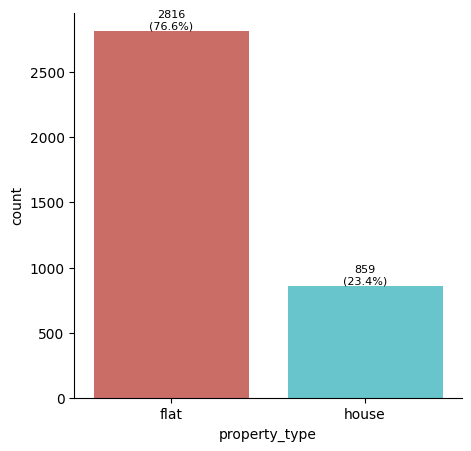

In [45]:
plt.figure(figsize=(5, 5))              # Set the figure size (width, height) 

ax = sns.countplot(data=df, x='property_type', palette='hls')

total = len(df)

for c in ax.containers:
    ax.bar_label(
        c,
        labels=[f'{int(v.get_height())}\n({v.get_height()/total:.1%})' for v in c],
        fontsize=8
    )

sns.despine()

-Observations

- Flats are in majority(76.6 percent) and there are less number of houses(23.4 percent)
- No missing values

<br>

#### **<span style="color:black">2. sector</span>**

In [65]:
# unique sectors
df['sector'].value_counts().sum()

np.int64(3675)

In [67]:
df['sector'].isna().sum()

np.int64(0)

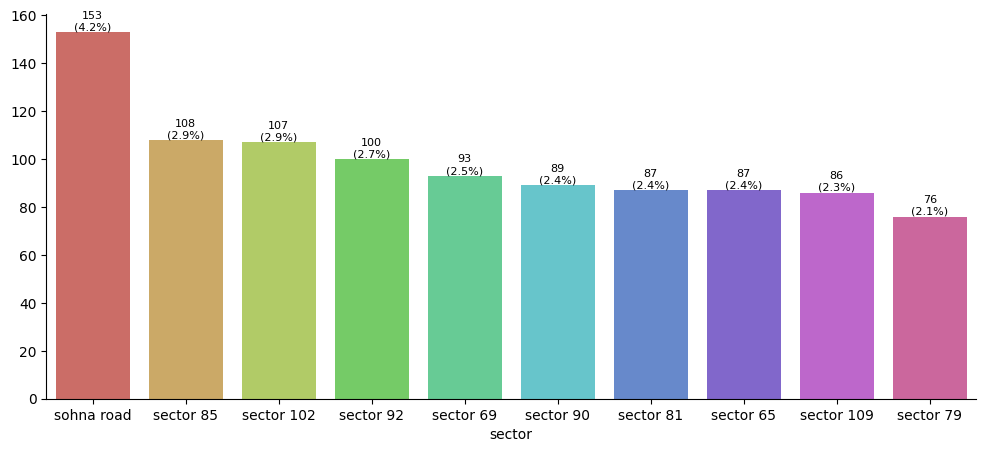

In [56]:
plt.figure(figsize=(12, 5))  
top10 = df['sector'].value_counts().head(10)

ax = sns.barplot(x=top10.index, y=top10.values, palette='hls')

total = len(df)

for c in ax.containers:
    ax.bar_label(
        c,
        labels=[f'{int(v.get_height())}\n({v.get_height()/total:.1%})' for v in c],
        fontsize=8
    )

sns.despine()

In [71]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

for k, v in sector_frequency_bins.items():
    print(f"{k:<20} : {v}")

Very High (>100)     : 3
High (50-100)        : 25
Average (10-49)      : 63
Low (2-9)            : 21
Very Low (1)         : 1


-Observations

- There are a total of 104 unique sectors in the dataset.
- Frequency distribution of sectors:
    - Very High (>100): 3 sectors have more than 100 listings.
    - High (50-100): 25 sectors have between 50 to 100 listings.
    - Average (10-49): A majority, 60 sectors, fall in this range with 10 to 49 listings each.
    - Low (2-9): 16 sectors have between 2 to 9 listings.
    - Very Low (1): Interestingly, there are no sectors with only 1 listing.

<br>

#### **<span style="color:black">3. price</span>**

In [75]:
df['price'].isnull().sum()

np.int64(17)

In [76]:
df['price'].describe()

count    3658.000000
mean        2.534732
std         2.981088
min         0.070000
25%         0.950000
50%         1.525000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

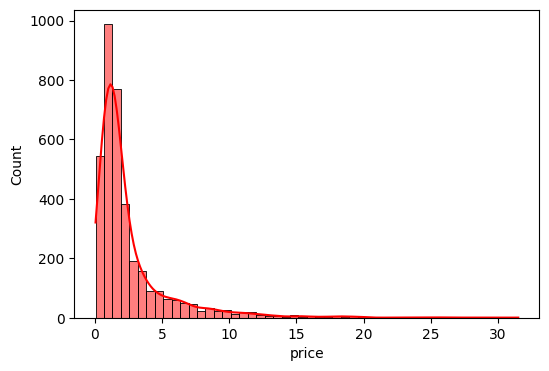

In [83]:
plt.figure(figsize=(6, 4))  
sns.histplot(df['price'], kde=True, bins=50, color='Red')

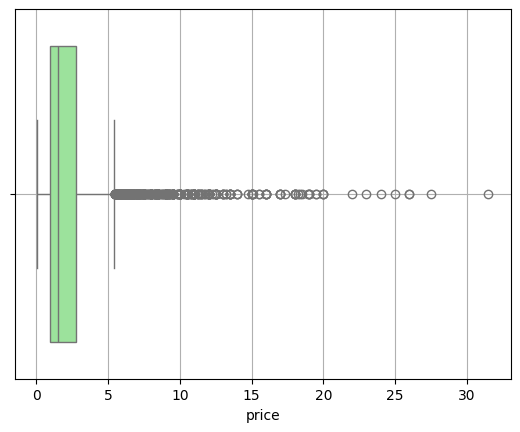

In [84]:
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

- Descriptive Statistics:

    - Count: There are 3,660 non-missing price entries.
    - Mean Price: The average price is approximately 2.53 crores.
    - Median Price: The median (or 50th percentile) price is 1.52 crores.
    - Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.
    - Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
    - IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.


- Visualizations:

    - Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
    - Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.
 

- Missing Values: There are 17 missing values in the price column.

In [85]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.2785095252761507 14.92720533001814


**Skewness**: The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

**Kurtosis**: The kurtosis value is approximately 14.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [ ]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])      # This shows the property price values below which 1%, 5%, 95%, and 99% of the data fall.

quantiles

0.01     0.250
0.05     0.370
0.95     8.500
0.99    15.264
Name: price, dtype: float64

Quantile Analysis:

- 1% Quantile: Only 1% of properties are priced below 0.25 crores.
- 5% Quantile: 5% of properties are priced below 0.37 crores.
- 95% Quantile: 95% of properties are priced below 8.5 crores.
- 99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.

<br>

log Transformation

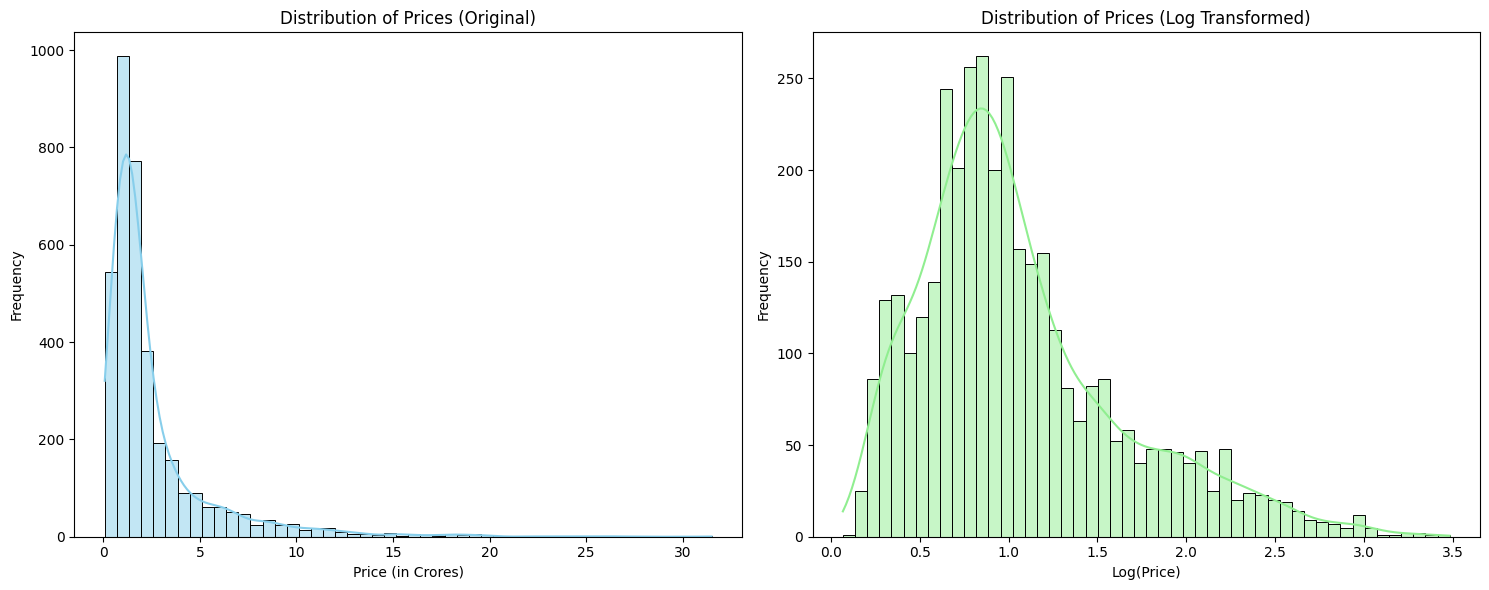

In [94]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

np.log1p(x): This function computes the natural logarithm of 1+x. 
It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [104]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0740709565255315 0.9646692415449296


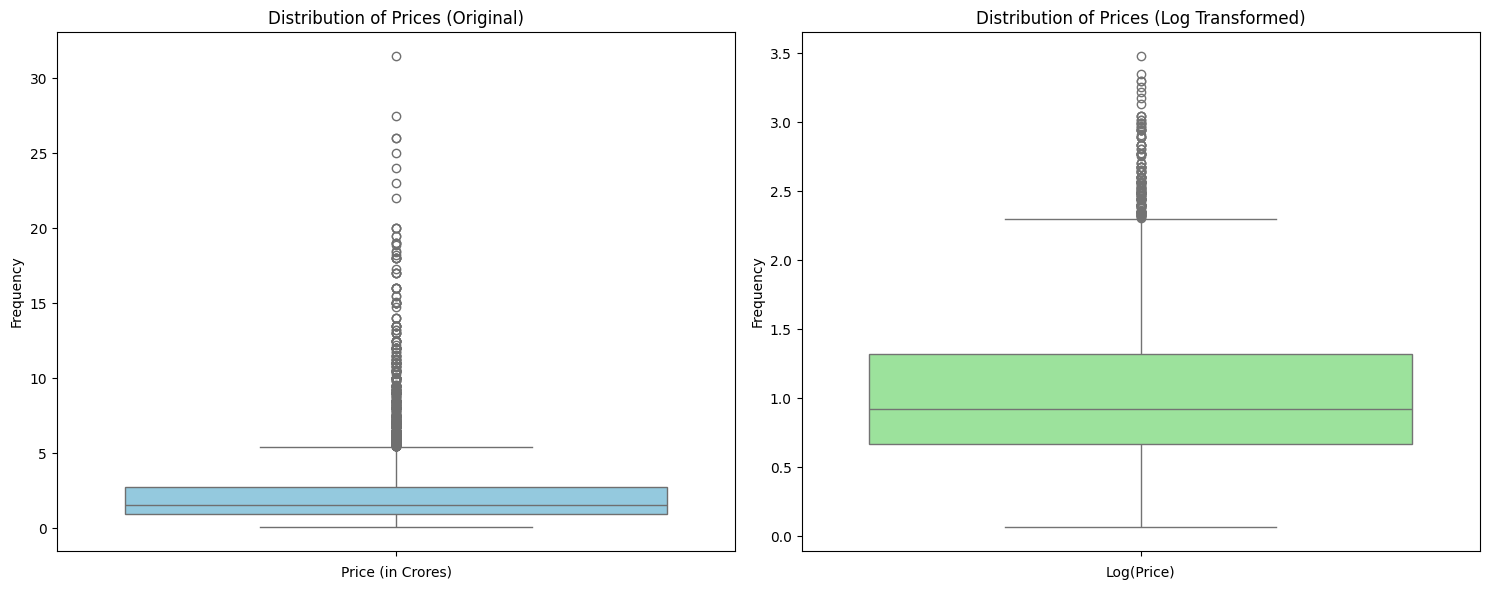

In [95]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<br>

#### **<span style="color:black">4. price_per_sqft</span>**

In [96]:
df['price_per_sqft'].isnull().sum()

np.int64(17)

In [97]:
df['price_per_sqft'].describe()

count      3658.000000
mean      13896.170312
std       23215.924214
min           4.000000
25%        6818.000000
50%        9021.000000
75%       13885.500000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

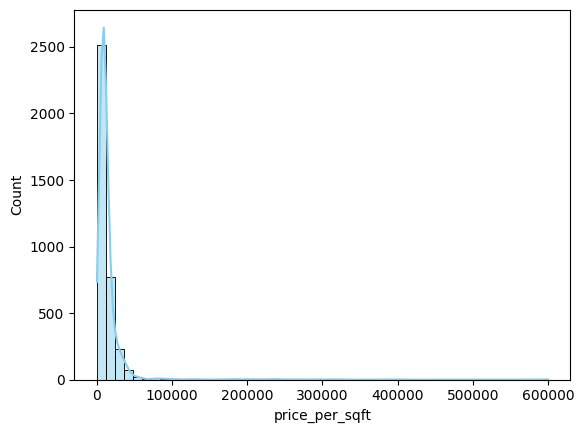

In [98]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

<Axes: ylabel='price_per_sqft'>

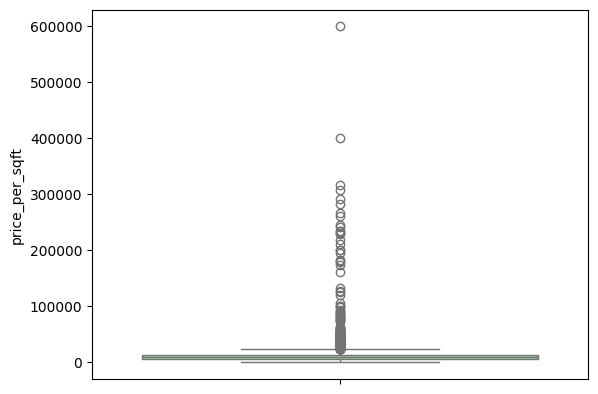

In [99]:
sns.boxplot(df['price_per_sqft'], color='lightgreen')

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

-Observations

- Potential Outliers
- Right Skewed
- 17 missing values

<br>

#### **<span style="color:black">5. bedRoom</span>**

In [100]:
df['bedRoom'].isnull().sum()

np.int64(0)

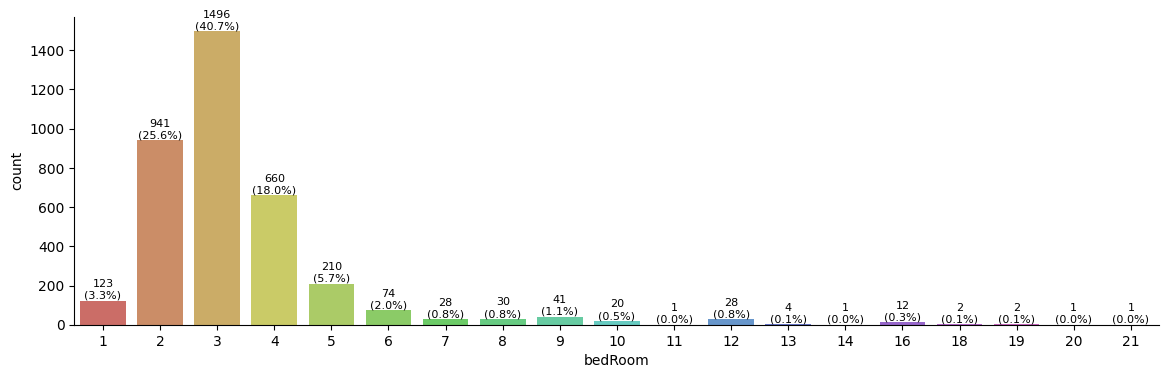

In [106]:
plt.figure(figsize=(14, 4))
ax = sns.countplot(data=df, x='bedRoom', palette='hls')

total = len(df)

for c in ax.containers:
    ax.bar_label(
        c,
        labels=[f'{int(v.get_height())}\n({v.get_height()/total:.1%})' for v in c],
        fontsize=8
    )

sns.despine()


<Axes: ylabel='count'>

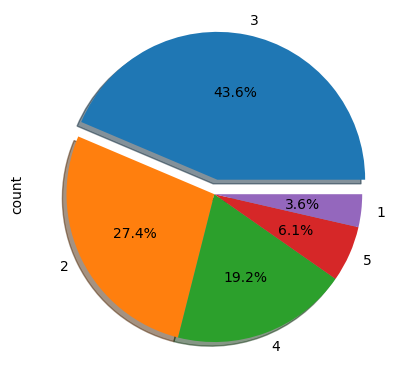

In [113]:
df['bedRoom'].value_counts().head().plot(kind='pie', autopct='%1.1f%%', shadow=True, explode = [0.1, 0, 0, 0, 0])

<br>

#### **<span style="color:black">6. bathroom</span>**

In [114]:
df['bathroom'].isnull().sum()

np.int64(0)

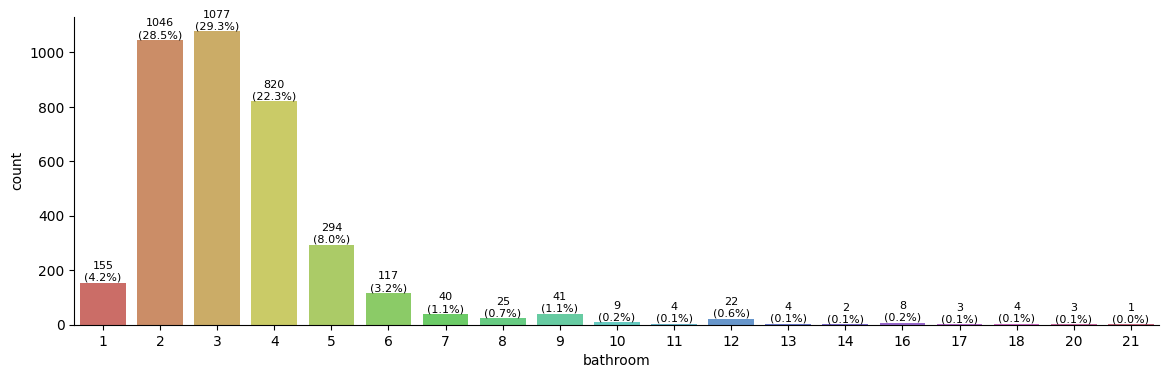

In [116]:
plt.figure(figsize=(14, 4))
ax = sns.countplot(data=df, x='bathroom', palette='hls')

total = len(df)

for c in ax.containers:
    ax.bar_label(
        c,
        labels=[f'{int(v.get_height())}\n({v.get_height()/total:.1%})' for v in c],
        fontsize=8
    )

sns.despine()


<br>

#### **<span style="color:black">7. balcony</span>**

In [127]:
df['balcony'].isnull().sum()

0

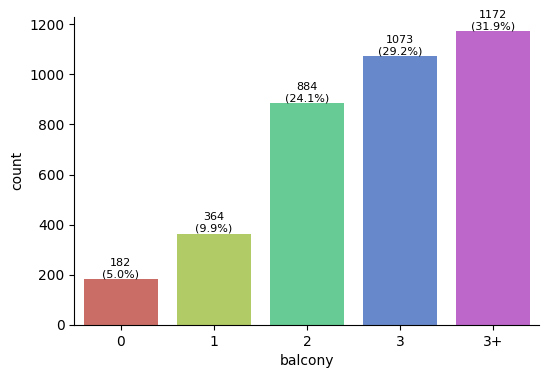

In [122]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='balcony', palette='hls', order=sorted(df['balcony'].unique()))

total = len(df)

for c in ax.containers:
    ax.bar_label(
        c,
        labels=[f'{int(v.get_height())}\n({v.get_height()/total:.1%})' for v in c],
        fontsize=8
    )

sns.despine()


<Axes: ylabel='count'>

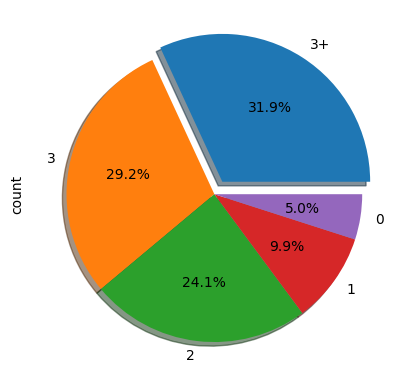

In [127]:
df['balcony'].value_counts().plot(kind='pie', autopct='%1.1f%%', shadow=True, explode = [0.1, 0, 0, 0, 0])

<br>

#### **<span style="color:black">8. facing</span>**

In [129]:
df['facing'].isnull().sum()

np.int64(1045)

In [130]:
df['facing'].fillna('NA',inplace=True)

In [131]:
df['facing'].value_counts()

facing
NA            1045
East           623
North-East     622
North          387
West           249
South          230
North-West     193
South-East     173
South-West     153
Name: count, dtype: int64

<br>

#### **<span style="color:black">9. agePossession</span>**

In [132]:
df['agePossession'].isnull().sum()

np.int64(0)

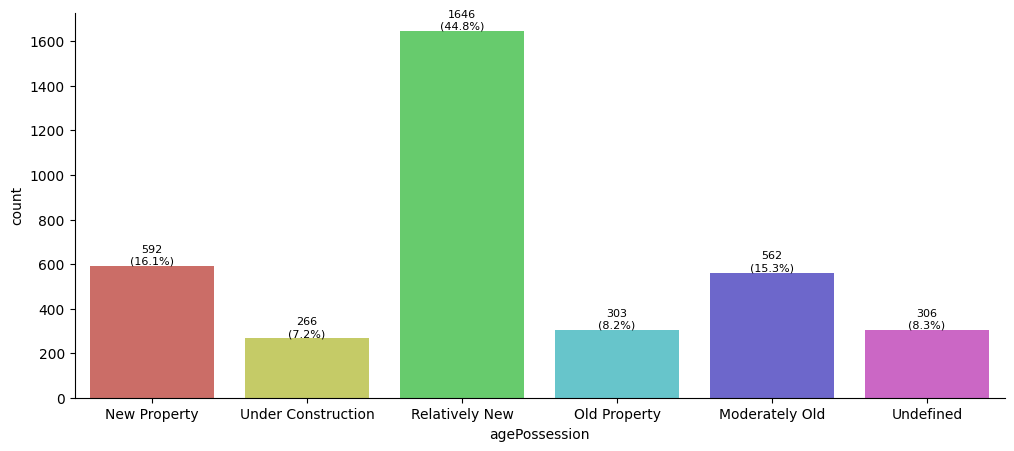

In [136]:
plt.figure(figsize=(12, 5))
ax = sns.countplot(data=df, x='agePossession', palette='hls')

total = len(df)

for c in ax.containers:
    ax.bar_label(
        c,
        labels=[f'{int(v.get_height())}\n({v.get_height()/total:.1%})' for v in c],
        fontsize=8
    )

sns.despine()


<br>

#### **<span style="color:black">10. areas</span>**

<br>

##### **<span style="color:black">i. super built up area</span>**

In [137]:
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1801)

In [138]:
df['super_built_up_area'].describe()

count     1874.000000
mean      1925.872759
std        763.880964
min         89.000000
25%       1480.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

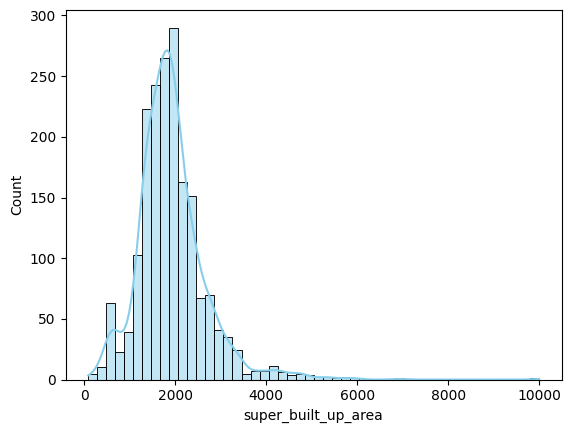

In [139]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

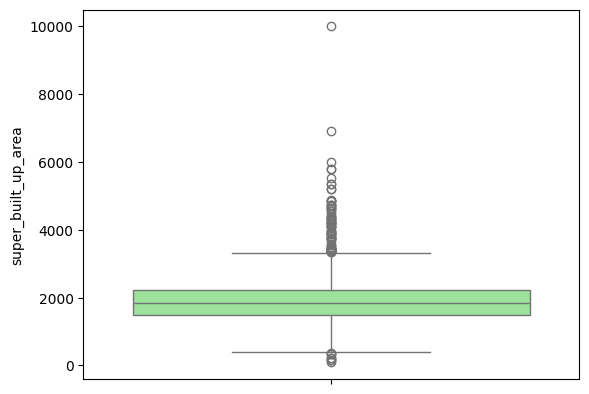

In [140]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

- Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
- There are a few properties with a significantly larger area, leading to a right-skewed distribution.
- The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
- There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

<br>

##### **<span style="color:black">ii. built up area</span>**

In [142]:
# built up area
df['built_up_area'].isnull().sum()

np.int64(1985)

In [143]:
df['built_up_area'].describe()

count      1690.000000
mean       2379.585816
std       17942.880237
min           2.000000
25%        1100.000000
50%        1650.000000
75%        2400.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

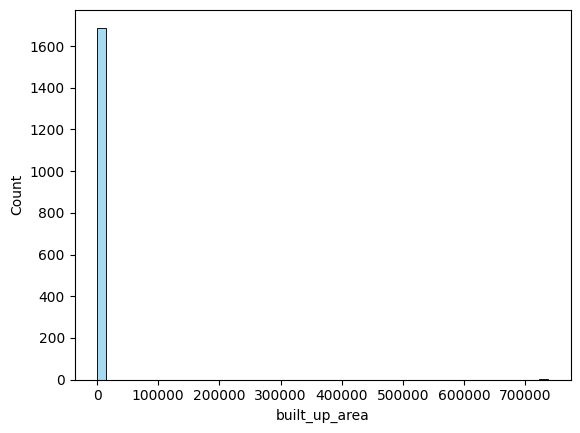

In [144]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

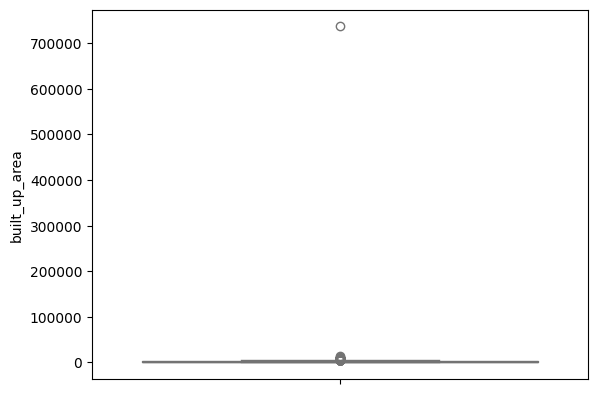

In [145]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

- Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
- There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
- The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.


The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

<br>

##### **<span style="color:black">iii. carpet area</span>**

In [146]:
# carpet area
df['carpet_area'].isnull().sum()

np.int64(1804)

In [147]:
df['carpet_area'].describe()

count      1871.000000
mean       2530.091950
std       22805.897659
min          15.000000
25%         845.000000
50%        1300.000000
75%        1790.000000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

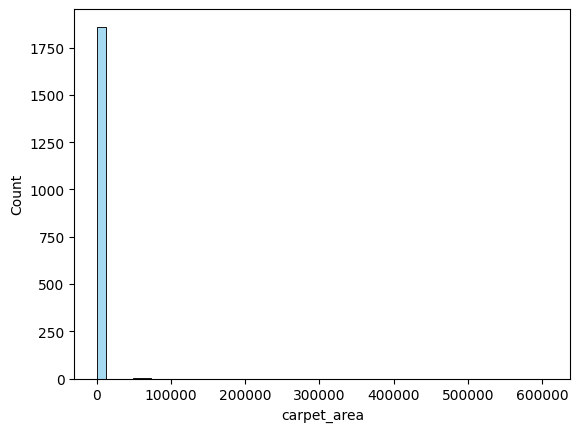

In [148]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='carpet_area'>

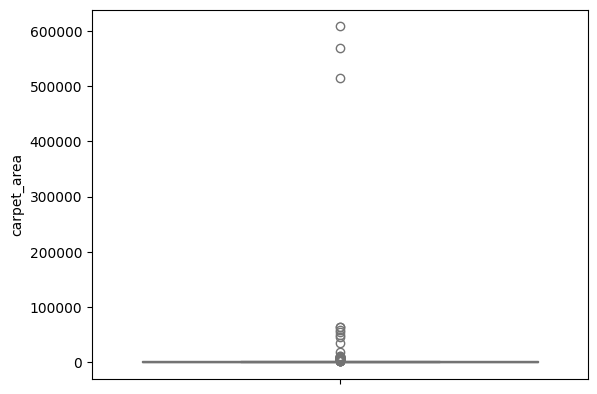

In [149]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')

<br>

#### **<span style="color:black">11. additional rooms</span>**

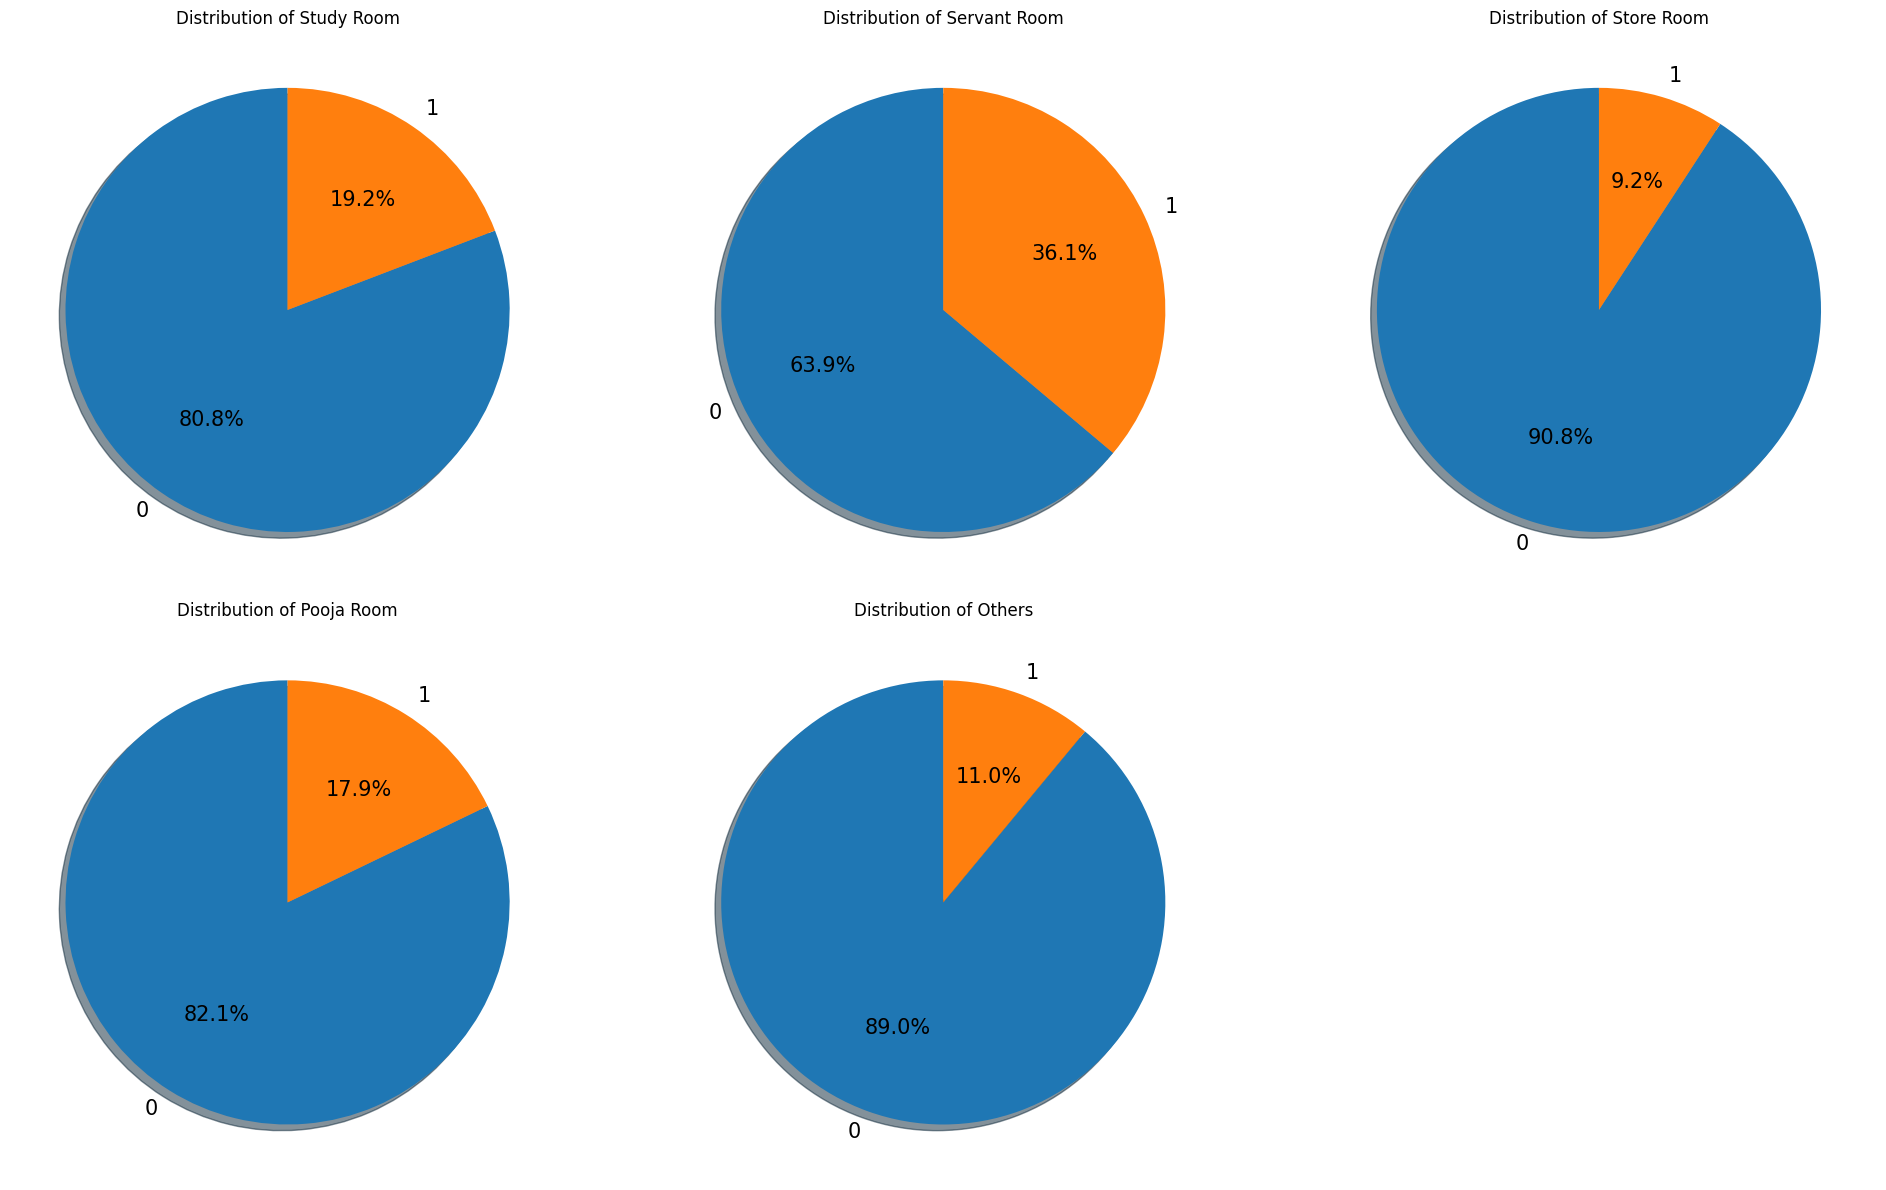

In [159]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%',shadow=True, startangle=90, ax=ax, textprops={'fontsize': 15})
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

<br>

#### **<span style="color:black">12. furnishing_type</span>**

In [154]:
df['furnishing_type'].value_counts()

furnishing_type
semifurnished    2435
furnished        1037
unfurnished       203
Name: count, dtype: int64

<Axes: ylabel='count'>

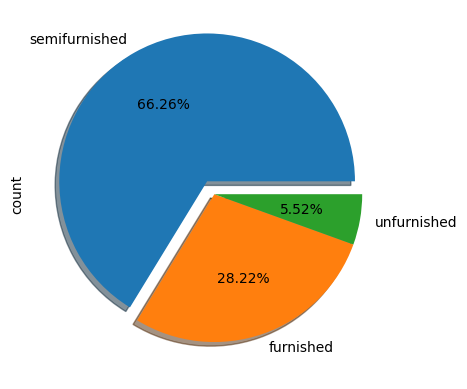

In [157]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%', explode= (0.1, 0, 0), shadow = True)